In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read Dataset

In [2]:
data = pd.read_csv("cardekho.csv")
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


## Data Description

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [4]:
data.describe().round(2)

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.00,8128.00,8128.00,7907.00,7907.00,7907.00
mean,2013.80,638271.81,69819.51,19.42,1458.63,5.42
std,4.04,806253.40,56550.55,4.04,503.92,0.96
min,1983.00,29999.00,1.00,0.00,624.00,2.00
25%,2011.00,254999.00,35000.00,16.78,1197.00,5.00
50%,2015.00,450000.00,60000.00,19.30,1248.00,5.00
75%,2017.00,675000.00,98000.00,22.32,1582.00,5.00
max,2020.00,10000000.00,2360457.00,42.00,3604.00,14.00


# Data Preprocessong

#### Convert **numeric Features** to **numeric datatype**

In [5]:
data['max_power'] = pd.to_numeric(data['max_power'], errors='coerce')

#### Remove **Unuseful Features**

In [6]:
data = data.drop(columns='seller_type')

In [7]:
data.head()

,name,year,selling_price,km_driven,fuel,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Manual,First Owner,16.10,1298.0,88.20,5.0


In [8]:
data.shape

(8128, 11)

### Check **Nulls** and remove them

In [9]:
data.isna().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             216
seats                 221
dtype: int64

In [10]:
data = data.dropna()

In [11]:
data.isna().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

### Check **Duplicates** and remove them

In [12]:
data.duplicated().sum()

1189

In [13]:
data = data.drop_duplicates()

In [14]:
data.duplicated().sum()

0

### Check **Outliers** and remove them

In [15]:
print(data[['km_driven', 'selling_price']].describe().round(2))

        km_driven  selling_price
count     6717.00        6717.00
mean     73398.34      526386.00
std      58703.28      523550.45
min          1.00       29999.00
25%      38000.00      250000.00
50%      68203.00      420000.00
75%     100000.00      650000.00
max    2360457.00    10000000.00


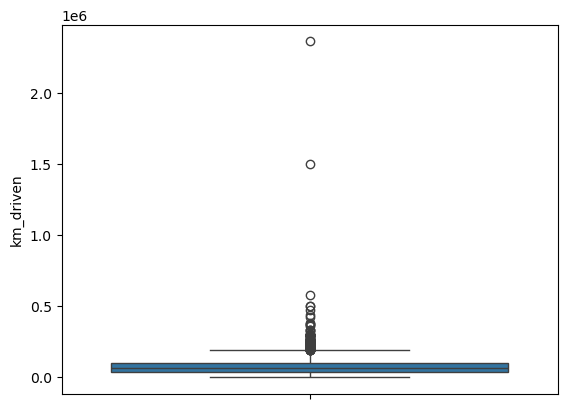

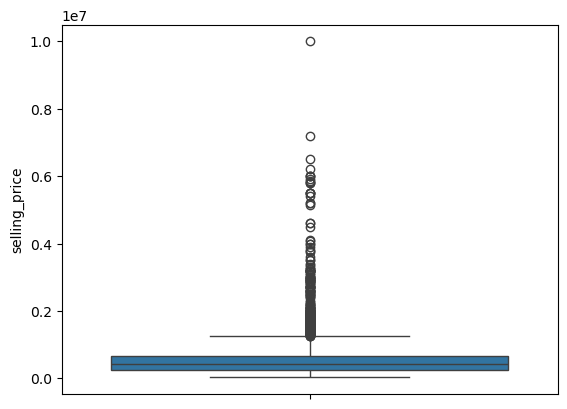

In [16]:
sns.boxplot(data['km_driven'])
plt.show()

sns.boxplot(data['selling_price'])
plt.show()

In [17]:
# Calculate Q1, Q3 and IQR
Q1 = data[['km_driven', 'selling_price']].quantile(0.25)
Q3 = data[['km_driven', 'selling_price']].quantile(0.75)
IQR = Q3 - Q1

In [18]:
# Filter out outliers based on IQR
data = data[~((data[['km_driven', 'selling_price']] < (Q1 - 1.5 * IQR)) | (data[['km_driven', 'selling_price']] > (Q3 + 1.5 * IQR))).any(axis=1)]

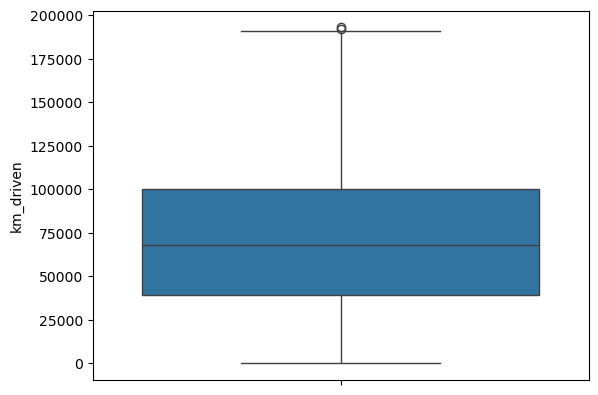

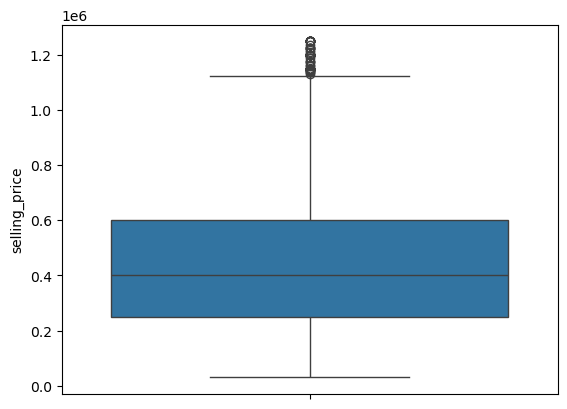

In [19]:
sns.boxplot(data['km_driven'])
plt.show()

sns.boxplot(data['selling_price'])
plt.show()

Visualization different charts

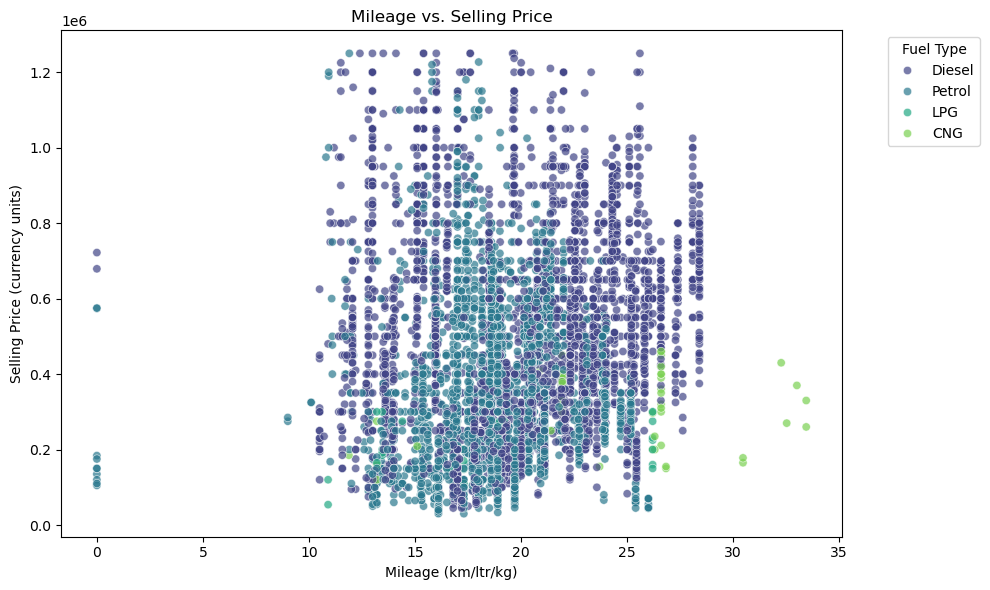

In [20]:
# Visualization 1: Scatter Plot - Mileage vs. Selling Price
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, 
    x="mileage(km/ltr/kg)", 
    y="selling_price", 
    hue="fuel", 
    palette="viridis", 
    alpha=0.7
)
plt.title("Mileage vs. Selling Price")
plt.xlabel("Mileage (km/ltr/kg)")
plt.ylabel("Selling Price (currency units)")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\Abdelrahman\AppData\Local\Temp\ipykernel_13444\980441756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="fuel", palette="pastel", order=data["fuel"].value_counts().index)


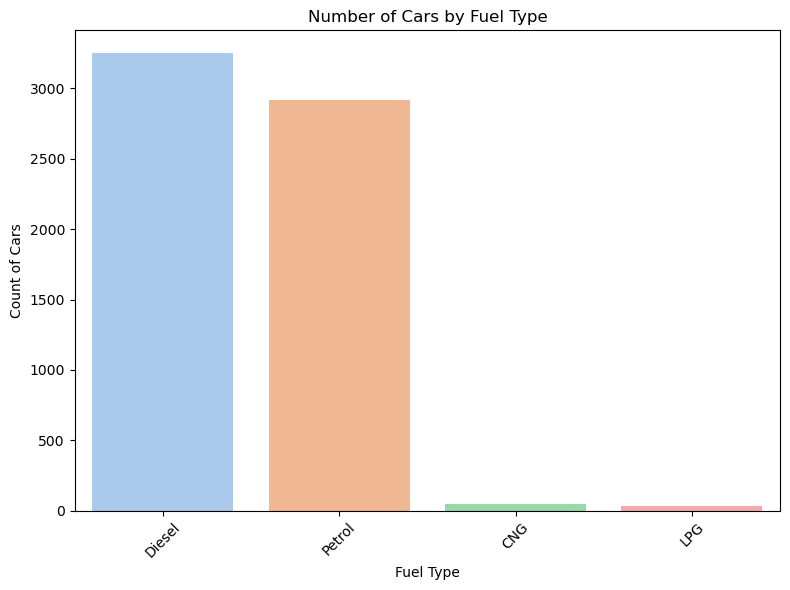

In [21]:
# Visualization 2: Bar Chart - Number of Cars by Fuel Type
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x="fuel", palette="pastel", order=data["fuel"].value_counts().index)
plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count of Cars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

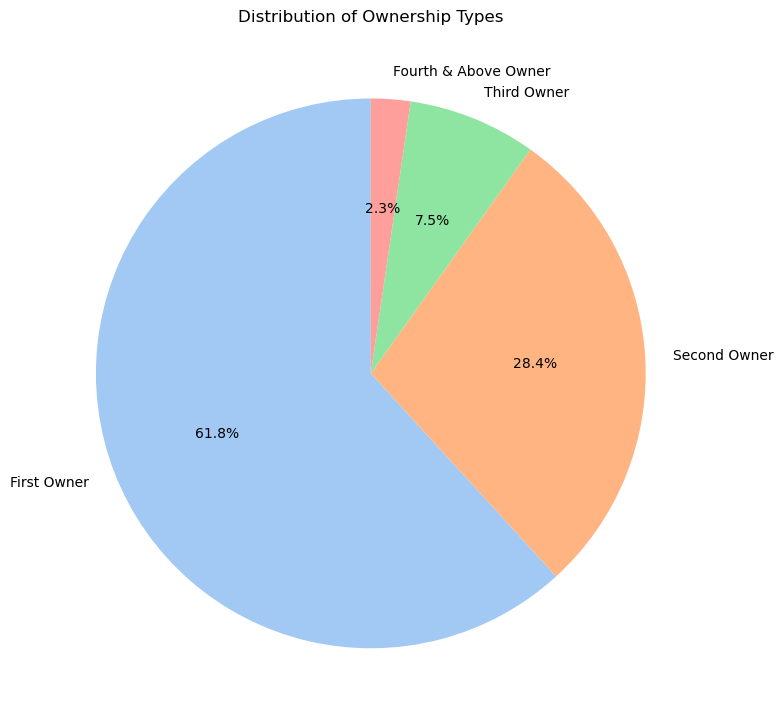

In [22]:
# Visualization 3: Pie Chart - Distribution of Ownership Types
plt.figure(figsize=(8, 8))
ownership_counts = data['owner'].value_counts()
plt.pie(
    ownership_counts, 
    labels=ownership_counts.index, 
    autopct='%1.1f%%', 
    colors=sns.color_palette("pastel"), 
    startangle=90
)
plt.title("Distribution of Ownership Types")
plt.tight_layout()
plt.show()

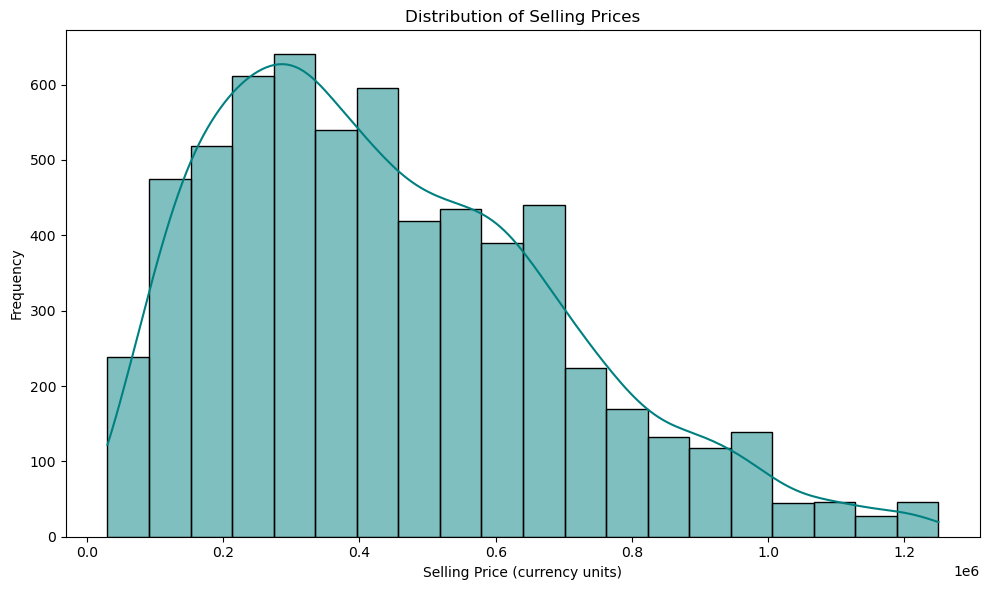

In [23]:
# Visualization 4: Histogram - Distribution of Selling Prices
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="selling_price", bins=20, kde=True, color="teal")
plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price (currency units)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


C:\Users\Abdelrahman\AppData\Local\Temp\ipykernel_13444\353594307.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="fuel", y="selling_price", palette="coolwarm")


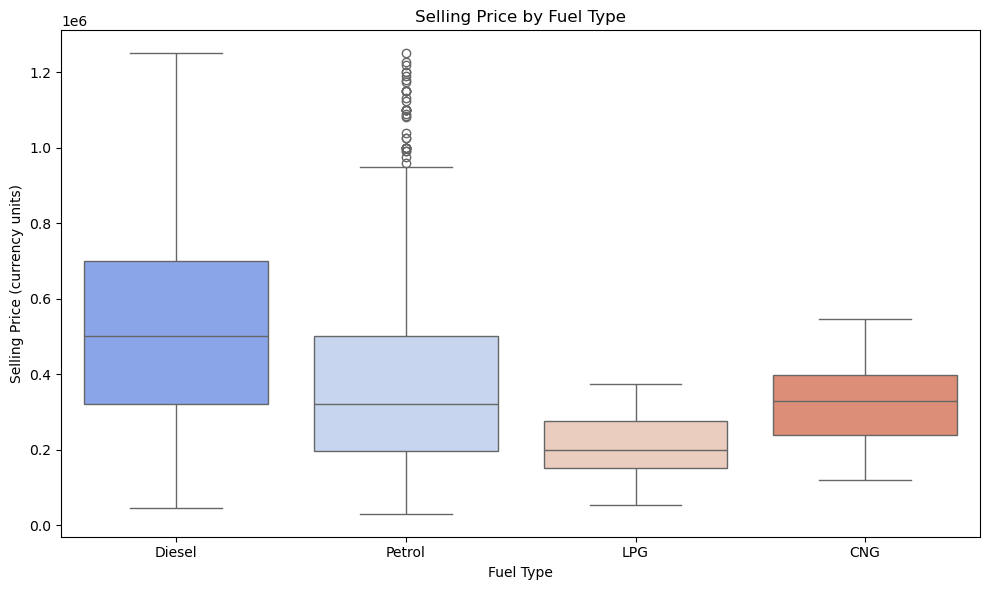

In [24]:
# Visualization 5: Box Plot - Selling Price by Fuel Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="fuel", y="selling_price", palette="coolwarm")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (currency units)")
plt.tight_layout()
plt.show()


C:\Users\Abdelrahman\AppData\Local\Temp\ipykernel_13444\730013503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="year", y="selling_price", palette="magma")


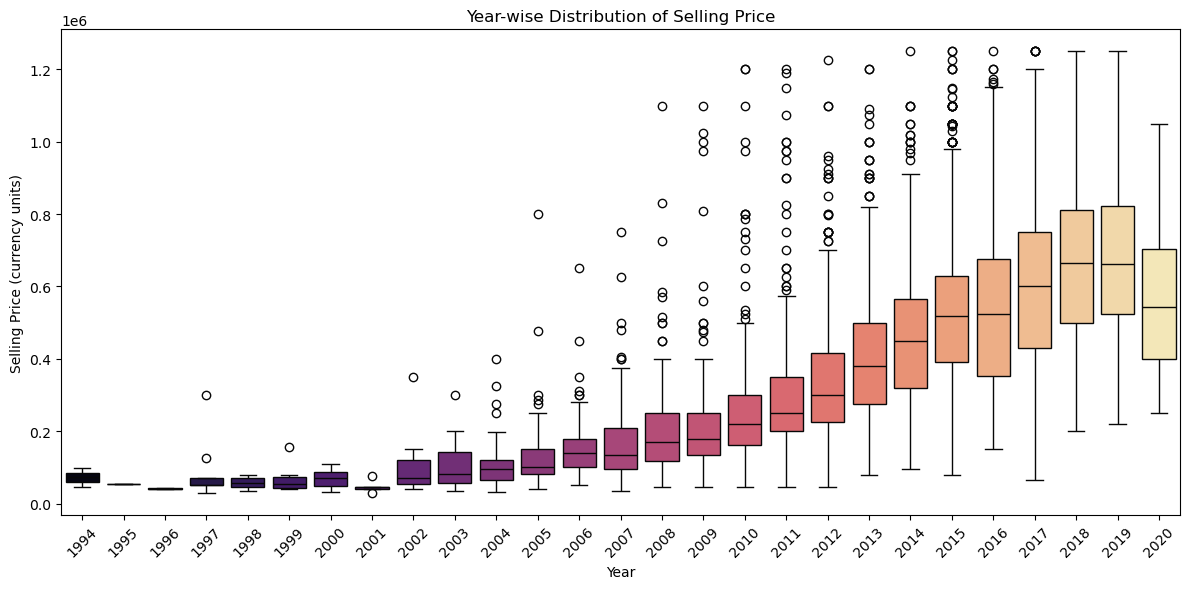

In [25]:
# 6 Year-wise Distribution of Selling Price
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x="year", y="selling_price", palette="magma")
plt.title("Year-wise Distribution of Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price (currency units)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

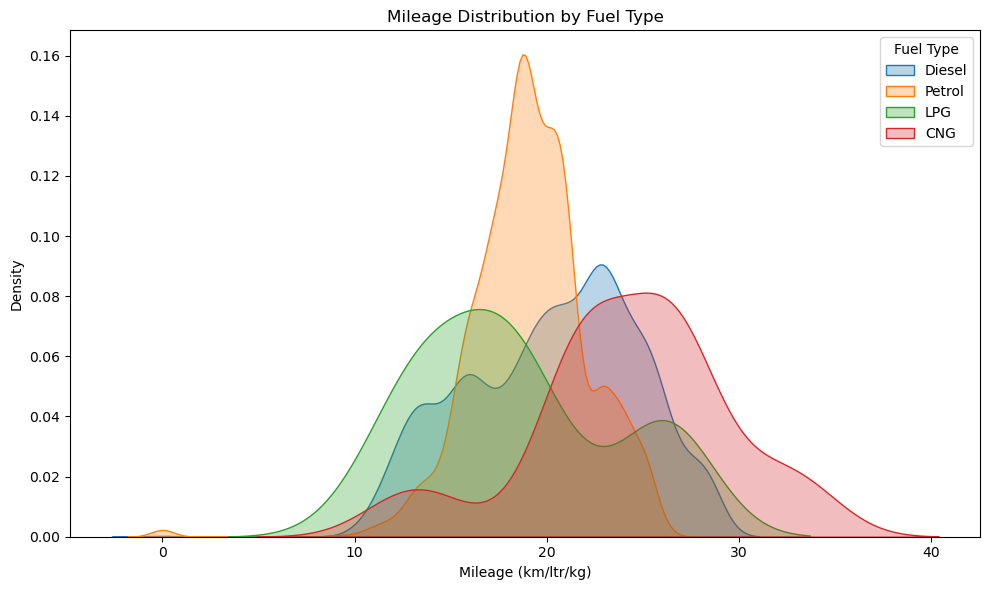

In [26]:
# 7 mileage Distribution by fuel type
plt.figure(figsize=(10, 6))
for fuel_type in data['fuel'].unique():
    sns.kdeplot(data[data['fuel'] == fuel_type]['mileage(km/ltr/kg)'], label=fuel_type, fill=True, alpha=0.3)
plt.title("Mileage Distribution by Fuel Type")
plt.xlabel("Mileage (km/ltr/kg)")
plt.ylabel("Density")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()


C:\Users\Abdelrahman\AppData\Local\Temp\ipykernel_13444\1527416299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="seats", palette="Set2", order=data["seats"].value_counts().index)


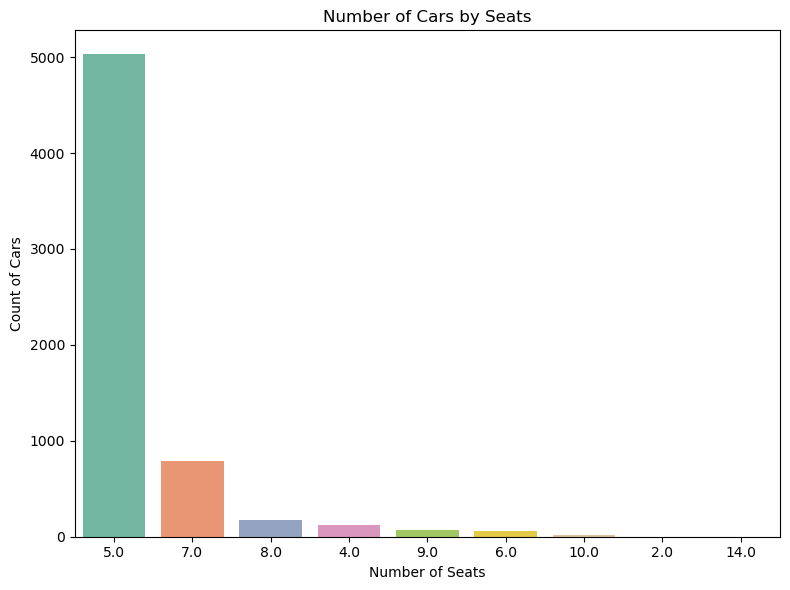

In [27]:
# 8 number of cars grouped by seats
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x="seats", palette="Set2", order=data["seats"].value_counts().index)
plt.title("Number of Cars by Seats")
plt.xlabel("Number of Seats")
plt.ylabel("Count of Cars")
plt.tight_layout()
plt.show()


C:\Users\Abdelrahman\AppData\Local\Temp\ipykernel_13444\2204141520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="transmission", y="selling_price", palette="muted")


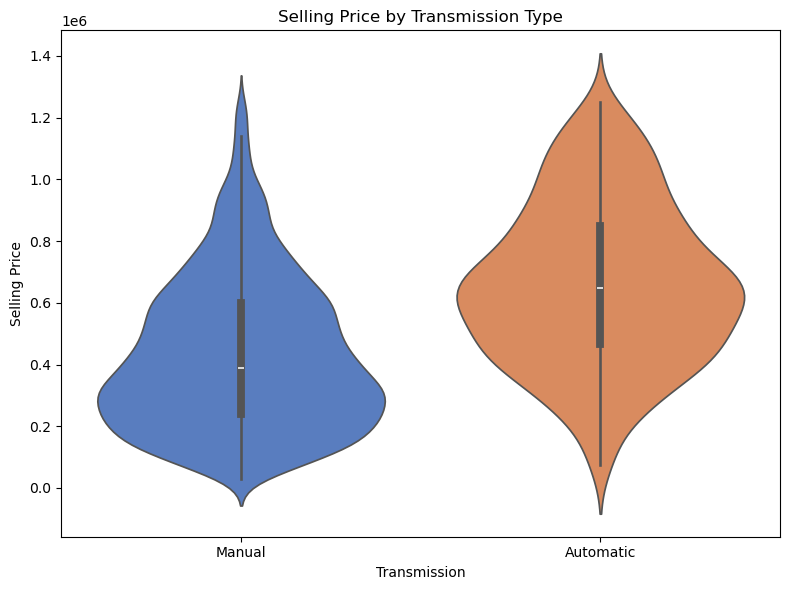

In [28]:
# 9 selling price by transmission type
plt.figure(figsize=(8, 6))
sns.violinplot(data=data, x="transmission", y="selling_price", palette="muted")
plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()


## Label Encoding.

In [29]:
data['owner'].value_counts()

owner
First Owner             3861
Second Owner            1773
Third Owner              471
Fourth & Above Owner     145
Name: count, dtype: int64

In [30]:
data['fuel'].value_counts()

fuel
Diesel    3250
Petrol    2916
CNG         50
LPG         34
Name: count, dtype: int64

In [31]:
data['transmission'].value_counts()

transmission
Manual       5874
Automatic     376
Name: count, dtype: int64

In [32]:
from sklearn.preprocessing import LabelEncoder

In [33]:
encode = LabelEncoder()

In [34]:
data_label = data.copy()

In [35]:
data_label['owner'] = encode.fit_transform(data_label['owner'])
data_label['fuel'] = encode.fit_transform(data_label['fuel'])
data_label['transmission'] = encode.fit_transform(data_label['transmission'])

In [36]:
data_label['owner'].value_counts() , data_label['fuel'].value_counts() , data_label['transmission'].value_counts()

(owner
 0    3861
 2    1773
 3     471
 1     145
 Name: count, dtype: int64,
 fuel
 1    3250
 3    2916
 0      50
 2      34
 Name: count, dtype: int64,
 transmission
 1    5874
 0     376
 Name: count, dtype: int64)

In [37]:
# data_label['owner'] = data_label['owner'].map({"First Owner":1, "Second Owner":2, "Third Owner":3, "Fourth & Above Owner":4})
# data_label['transmission'] = data_label['transmission'].map({"Manual":1, "Automatic":2})
# data_label['fuel'] = data_label['fuel'].map({"Diesel":1, "Petrol":2, "CNG":3, "LPG":4})

# OR
# pd.get_dummies(data_label['fuel'], prefix='fuel')

In [38]:
data_label.head()

,name,year,selling_price,km_driven,fuel,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,1,1,0,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,1,1,2,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,3,1,3,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,1,0,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,3,1,0,16.10,1298.0,88.20,5.0


In [39]:
data_label.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6250 entries, 0 to 8125
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6250 non-null   object 
 1   year                6250 non-null   int64  
 2   selling_price       6250 non-null   int64  
 3   km_driven           6250 non-null   int64  
 4   fuel                6250 non-null   int32  
 5   transmission        6250 non-null   int32  
 6   owner               6250 non-null   int32  
 7   mileage(km/ltr/kg)  6250 non-null   float64
 8   engine              6250 non-null   float64
 9   max_power           6250 non-null   float64
 10  seats               6250 non-null   float64
dtypes: float64(4), int32(3), int64(3), object(1)
memory usage: 641.7+ KB


In [40]:
data.describe().round(2)

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6250.00,6250.00,6250.00,6250.00,6250.00,6250.00,6250.00
mean,2013.55,444491.00,69705.26,19.76,1375.91,83.64,5.38
std,3.88,253225.24,39716.98,3.92,445.28,25.55,0.94
min,1994.00,29999.00,1.00,0.00,624.00,32.80,2.00
25%,2011.00,250000.00,39000.00,17.10,1196.00,67.10,5.00
50%,2014.00,400000.00,68171.50,19.70,1248.00,81.80,5.00
75%,2017.00,600000.00,100000.00,22.71,1497.00,97.70,5.00
max,2020.00,1250000.00,193000.00,33.44,3498.00,272.00,14.00


اmost brand sold : Maruti : 2072

أmost 10 brand sold:
brand
Maruti           2072
Hyundai          1193
Mahindra          647
Tata              601
Honda             350
Ford              340
Chevrolet         206
Renault           202
Toyota            193
Volkswagen        167
Nissan             72
Skoda              60
Datsun             57
Fiat               38
BMW                14
Mercedes-Benz      11
Mitsubishi          7
Force               4
Audi                4
Ambassador          4
Name: count, dtype: int64


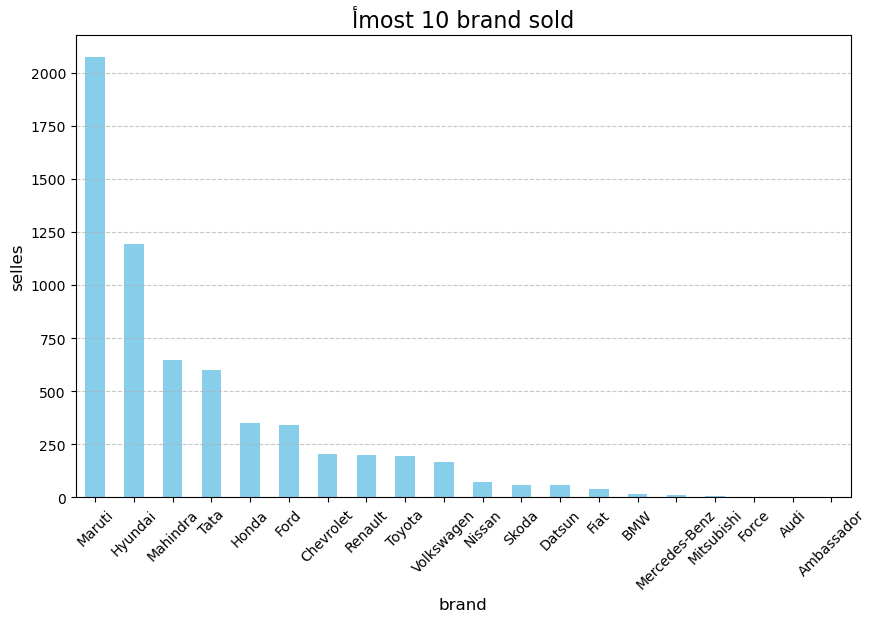

In [41]:
data['brand'] = data['name'].apply(lambda x: str(x).split()[0])


brand_counts = data['brand'].value_counts()

most_sold_brand = brand_counts.idxmax()
most_sold_count = brand_counts.max()
print(f"اmost brand sold : {most_sold_brand} : {most_sold_count}")
print("\nأmost 10 brand sold:")
print(brand_counts.head(20))
top_brands = brand_counts.head(20)
plt.figure(figsize=(10, 6))
top_brands.plot(kind='bar', color='skyblue')
plt.title("أmost 10 brand sold", fontsize=16)
plt.xlabel("brand", fontsize=12)
plt.ylabel("selles", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
data = data.drop(columns=['brand'])

## Text Preprocessing

In [42]:
data[data['name'].str.contains('Honda', case=False, na=False)]['selling_price'].shape

(350,)

In [43]:
data[data['name'] == 'Honda City 2017-2020 EXi']['selling_price'].shape

(7,)

In [44]:
data[(data['name'] == 'Honda City 2017-2020 EXi') & (data['year'] == 2006)]['selling_price'].shape

(2,)

In [45]:
data_label['name']

0                  Maruti Swift Dzire VDI
1            Skoda Rapid 1.5 TDI Ambition
2                Honda City 2017-2020 EXi
3               Hyundai i20 Sportz Diesel
4                  Maruti Swift VXI BSIII
                      ...                
8121    Maruti Wagon R VXI BS IV with ABS
8122           Hyundai i20 Magna 1.4 CRDi
8123                    Hyundai i20 Magna
8124                Hyundai Verna CRDi SX
8125               Maruti Swift Dzire ZDi
Name: name, Length: 6250, dtype: object

In [46]:
data_label['brand'] = data_label['name'].str.split(' ').str[0]
# data_label['brand'] = data_label['name'].apply(lambda x: x.split()[0])  # First word as Brand

data_label['model'] = data_label['name'].apply(lambda x: " ".join(x.split()[1:]))  # Rest as Model
data_label = data_label.drop(columns='name')

In [47]:
# Move 'brand' and 'model' to the first two columns
cols = ['brand', 'model'] + [col for col in data_label.columns if col not in ['brand', 'model']]
data_label = data_label[cols]

In [48]:
data_label

,brand,model,year,selling_price,km_driven,fuel,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti,Swift Dzire VDI,2014,450000,145500,1,1,0,23.40,1248.0,74.00,5.0
1,Skoda,Rapid 1.5 TDI Ambition,2014,370000,120000,1,1,2,21.14,1498.0,103.52,5.0
2,Honda,City 2017-2020 EXi,2006,158000,140000,3,1,3,17.70,1497.0,78.00,5.0
3,Hyundai,i20 Sportz Diesel,2010,225000,127000,1,1,0,23.00,1396.0,90.00,5.0
4,Maruti,Swift VXI BSIII,2007,130000,120000,3,1,0,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti,Wagon R VXI BS IV with ABS,2013,260000,50000,3,1,2,18.90,998.0,67.10,5.0
8122,Hyundai,i20 Magna 1.4 CRDi,2014,475000,80000,1,1,2,22.54,1396.0,88.73,5.0
8123,Hyundai,i20 Magna,2013,320000,110000,3,1,0,18.50,1197.0,82.85,5.0
8124,Hyundai,Verna CRDi SX,2007,135000,119000,1,1,1,16.80,1493.0,110.00,5.0


In [49]:
data_prep = data_label.copy()

### one-hot encoding

In [50]:
# Apply One-Hot Encoding for 'brand' and 'model'
data_prep = pd.get_dummies(data_prep, columns=['brand', 'model'], drop_first=True)

In [51]:
# Track the columns after one-hot encoding (used for alignment)
one_hot_columns = data_prep.columns.difference(['selling_price'])

In [52]:
data_prep

,year,selling_price,km_driven,fuel,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,...,model_i20 Magna 1.4 CRDi (Diesel),model_i20 Magna Optional 1.2,model_i20 Magna Optional 1.4 CRDi,model_i20 Petrol CVT Asta,model_i20 Sportz 1.2,model_i20 Sportz 1.4 CRDi,model_i20 Sportz AT 1.4,model_i20 Sportz Diesel,model_i20 Sportz Option 1.2,model_i20 Sportz Option 1.4 CRDi
0,2014,450000,145500,1,1,0,23.40,1248.0,74.00,5.0,...,False,False,False,False,False,False,False,False,False,False
1,2014,370000,120000,1,1,2,21.14,1498.0,103.52,5.0,...,False,False,False,False,False,False,False,False,False,False
2,2006,158000,140000,3,1,3,17.70,1497.0,78.00,5.0,...,False,False,False,False,False,False,False,False,False,False
3,2010,225000,127000,1,1,0,23.00,1396.0,90.00,5.0,...,False,False,False,False,False,False,False,True,False,False
4,2007,130000,120000,3,1,0,16.10,1298.0,88.20,5.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,2013,260000,50000,3,1,2,18.90,998.0,67.10,5.0,...,False,False,False,False,False,False,False,False,False,False
8122,2014,475000,80000,1,1,2,22.54,1396.0,88.73,5.0,...,False,False,False,False,False,False,False,False,False,False
8123,2013,320000,110000,3,1,0,18.50,1197.0,82.85,5.0,...,False,False,False,False,False,False,False,False,False,False
8124,2007,135000,119000,1,1,1,16.80,1493.0,110.00,5.0,...,False,False,False,False,False,False,False,False,False,False


# Clustering using K_Medoids

In [53]:
pip install scikit-learn-extra

In [54]:
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [55]:
scaler = StandardScaler()
data_clustering = scaler.fit_transform(data_label[['selling_price', 'max_power']])


In [56]:
kmedoids = KMedoids(n_clusters=3, random_state=42)
labels = kmedoids.fit_predict(data_clustering)
labels


array([2, 1, 0, ..., 0, 0, 0], dtype=int64)

In [57]:
data_label['luxuriousness_level'] = labels


In [58]:
medoid_indices = kmedoids.medoid_indices_
medoid_points = data_label.iloc[medoid_indices]
medoid_points

,brand,model,year,selling_price,km_driven,fuel,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,luxuriousness_level
5769,Hyundai,i10 Era,2013,245000,110000,3,1,2,19.81,1086.0,68.05,5.0,0
2218,Ford,EcoSport 1.5 Petrol Trend BSIV,2017,604000,30000,3,1,2,17.00,1497.0,121.36,5.0,1
117,Maruti,Swift Dzire VXI,2017,595000,40000,3,1,0,20.85,1197.0,83.14,5.0,2


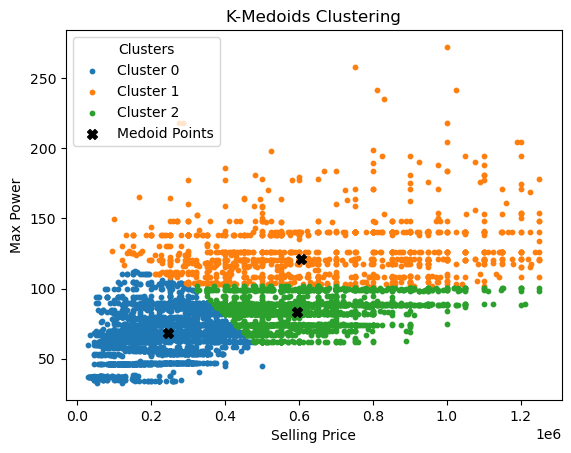

In [59]:
for cluster_label in range(kmedoids.n_clusters):
    cluster_data = data_label[data_label['luxuriousness_level'] == cluster_label]
    plt.scatter(
        cluster_data['selling_price'],
        cluster_data['max_power'],
        label=f'Cluster {cluster_label}',
        s=10
    )

plt.scatter(
    medoid_points['selling_price'],
    medoid_points['max_power'],
    color='black',  
    label='Medoid Points',
    s=50,  
    marker='X'  
)

plt.xlabel('Selling Price')
plt.ylabel('Max Power')
plt.title('K-Medoids Clustering')
plt.legend(title='Clusters')
plt.show()

In [60]:
numeric_cols = data_label.select_dtypes(include=['float64', 'int64']).columns
encoded_col = data_label.select_dtypes(include=['int32']).columns
cluster_info = data_label.groupby('luxuriousness_level')[numeric_cols].mean()
cluster_info2 = data_label.groupby('luxuriousness_level')[encoded_col].agg(lambda x: x.mode()[0])
cluster_info = pd.concat([cluster_info, cluster_info2], axis=1)
cluster_info['count'] = data_label.groupby('luxuriousness_level').size()
cluster_info


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,luxuriousness_level,fuel,transmission,owner,count
luxuriousness_level,,,,,,,,,,,,
0,2011.654798,241608.312309,75611.413700,19.752899,1180.457104,67.410926,5.134283,0.0,3,1,0,2949
1,2013.407136,648098.774931,79230.915828,16.577127,1861.775846,126.103536,5.851784,1.0,1,1,0,1093
2,2016.160779,614671.144475,57101.641304,21.358297,1396.434330,84.283265,5.480525,2.0,1,1,0,2208


In [61]:
luxuriousness_levels = ['Economy', 'Comfort', 'Luxury']
data_label['luxuriousness_level'] = pd.Categorical(data_label['luxuriousness_level'], categories=[0, 2, 1]).rename_categories(luxuriousness_levels)

In [62]:
data_label.head()

,brand,model,year,selling_price,km_driven,fuel,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,luxuriousness_level
0,Maruti,Swift Dzire VDI,2014,450000,145500,1,1,0,23.40,1248.0,74.00,5.0,Comfort
1,Skoda,Rapid 1.5 TDI Ambition,2014,370000,120000,1,1,2,21.14,1498.0,103.52,5.0,Luxury
2,Honda,City 2017-2020 EXi,2006,158000,140000,3,1,3,17.70,1497.0,78.00,5.0,Economy
3,Hyundai,i20 Sportz Diesel,2010,225000,127000,1,1,0,23.00,1396.0,90.00,5.0,Economy
4,Maruti,Swift VXI BSIII,2007,130000,120000,3,1,0,16.10,1298.0,88.20,5.0,Economy


# Machine Learning

#### To create a **machine learning model** that predicts the **selling price** of a car based on the **car's model, brand and **year**, and then provides similar car specifications

## Model Building

#### Use Random Forest Regression

### Split data

In [63]:
from sklearn.model_selection import train_test_split

# Features and target
X = data_prep[one_hot_columns]  # Use the one-hot encoded columns
y = data_prep['selling_price']  # Target variable

In [64]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Standardization

In [65]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler on training data
scaler = StandardScaler()

# scaler = StandardScaler().fit(X_train)

In [66]:
X_train_scaled = scaler.fit_transform(X_train)  # Scale training data
X_test_scaled = scaler.fit_transform(X_test) 
print(scaler.mean_)
print(scaler.scale_)
# Scale test data using the same scaler

[1.600000e-03 8.000000e-04 3.280000e-02 ... 5.353600e+00 9.384000e-01
 2.013504e+03]
[0.03996799 0.02827296 0.17811277 ... 0.89964829 0.24042762 3.84962128]


### Model Training

In [67]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [68]:
# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred

array([309444.68      , 491839.98      , 398476.65666667, ...,
       137966.64333333, 453431.66666667, 407289.97      ])

In [69]:
y_test

6459    299000
746     450000
7156    440000
5492    280000
5890    150000
         ...  
2053    380000
1889    120000
695     135000
584     500000
7247    770000
Name: selling_price, Length: 1250, dtype: int64

## Model Evaluation

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the model using MAE, MSE, and R² score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [71]:
# Print the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 62975.423092431745
Mean Squared Error (MSE): 7611362815.672786
R² Score: 0.8807675722548839


## Validation (Tuning Hyperparameters)

it will take almost 15 minutes

In [72]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5],
}

In [73]:
# # Grid Search
# grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=3)
# grid_search.fit(X_train, y_train)

In [74]:
# # Best parameters and model
# print(f'Best parameters: {grid_search.best_params_}')
# best_model = grid_search.best_estimator_
# print(best_model)

## Retrain Model

In [75]:
# Train the model with the best parameters
model = RandomForestRegressor(max_depth=30, min_samples_split=5, n_estimators=200, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=30, min_samples_split=5, n_estimators=200,
                      random_state=42)

In [76]:
# Predictions on test data
y_test_pred = model.predict(X_test_scaled)

# Calculate the performance on test data
print("\nTest Performance:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_test_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_test_pred)}")
print(f"R2 Score: {r2_score(y_test, y_test_pred)}")


Test Performance:
Mean Absolute Error: 62728.47035199182
Mean Squared Error: 7573206954.301268
R2 Score: 0.8813652859750425


## Model Testing

#### Price prediction

In [77]:
def preprocess_and_predict(new_data):
    print(new_data)
    # Manual mapping for categorical variables
    fuel_mapping = {'Diesel': 1, 'Petrol': 3, 'CNG': 0, 'LPG': 2}
    transmission_mapping = {'Manual': 1, 'Automatic': 0}
    owner_mapping = {
        'First Owner': 0,
        'Second Owner': 2,
        'Third Owner': 3,
        'Fourth & Above Owner': 1
    }

    # Apply the mappings
    if 'fuel' in new_data:
        new_data['fuel'] = new_data['fuel'].map(fuel_mapping)
    if 'transmission' in new_data:
        new_data['transmission'] = new_data['transmission'].map(transmission_mapping)
    if 'owner' in new_data:
        new_data['owner'] = new_data['owner'].map(owner_mapping)

    # Handle missing values after mapping
    new_data = new_data.fillna(0)

    # Split 'name' into 'brand' and 'model'
    if 'name' in new_data:
        new_data['brand'] = new_data['name'].str.split(' ').str[0]
        new_data['model'] = new_data['name'].apply(lambda x: " ".join(x.split()[1:]))
        new_data = new_data.drop(columns='name')

    # Apply one-hot encoding
    new_data_encoded = pd.get_dummies(new_data, columns=['brand', 'model'], drop_first=True)

    # Align columns with training data (handle missing or extra columns)
    new_data_aligned = pd.DataFrame(0, columns=one_hot_columns, index=new_data_encoded.index)  # Create a DataFrame with all one-hot columns
    new_data_aligned.update(new_data_encoded.astype(int))  # Update with the new_data_encoded
    print(new_data_aligned)

    # Scale the data
    scaled_data = scaler.transform(new_data_aligned)
    print(scaled_data)

    # Predict using the model
    predictions = model.predict(scaled_data)

    return predictions

In [79]:
# Example new data
new_data = pd.DataFrame({
    'name': ['Maruti Swift Dzire VDI'],
    'year': [2014],
    'km_driven': [145500],
    'fuel': ['Diesel'],
    'transmission': ['Manual'],
    'owner': ['First Owner'],
    'mileage(km/ltr/kg)': [23.4],
    'engine': [1248.0],
    'max_power': [74.0],
    'seats': [5.0]
})

# Make predictions
predictions = preprocess_and_predict(new_data)

print("Predictions:", predictions)

                     name  year  km_driven    fuel transmission        owner  \
0  Maruti Swift Dzire VDI  2014     145500  Diesel       Manual  First Owner   

   mileage(km/ltr/kg)  engine  max_power  seats  
0                23.4  1248.0       74.0    5.0  
   brand_Audi  brand_BMW  brand_Chevrolet  brand_Daewoo  brand_Datsun  \
0           0          0                0             0             0   

   brand_Fiat  brand_Force  brand_Ford  brand_Honda  brand_Hyundai  ...  \
0           0            0           0            0              0  ...   

   model_i20 Sportz 1.2  model_i20 Sportz 1.4 CRDi  model_i20 Sportz AT 1.4  \
0                     0                          0                        0   

   model_i20 Sportz Diesel  model_i20 Sportz Option 1.2  \
0                        0                            0   

   model_i20 Sportz Option 1.4 CRDi  owner  seats  transmission  year  
0                                 0      0      5             1  2014  

[1 rows x 1830 col

## Exactly Searching

In [89]:
def search_car(name, year):
    # Filter data based on brand, model, and year
    filtered_data = data[(data['name'] == name) & (data['year'] == year)]                               
    
    return filtered_data

In [90]:
# Example usage
name_input = 'Hyundai i20 Sportz Diesel'
year_input = 2010

result = search_car(name_input, year_input)
result

,name,year,selling_price,km_driven,fuel,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Manual,First Owner,23.0,1396.0,90.0,5.0


## Predicted Searching

In [91]:
 #!pip install fuzzywuzzy

In [92]:
from fuzzywuzzy import fuzz

def find_top_matches(name, year, top_n=3):
    # Create a list to store the scores and corresponding rows
    match_scores = []

    for index, row in data.iterrows():
        # Calculate the similarity for name
        name_score = fuzz.ratio(name.lower(), row['name'].lower())
        
        # Calculate the difference in year (lower difference is better)
        year_score = 1 / (1 + abs(row['year'] - year))  # Inverse of year difference
        
        # Combine scores (you can adjust weights as needed)
        combined_score = (name_score * 0.4) + (year_score * 0.2)
        
        # Append the combined score and the row to the list
        match_scores.append((combined_score, row))

    # Sort the matches by score in descending order (best match first)
    match_scores.sort(reverse=True, key=lambda x: x[0])

    # Return the top_n best matches
    top_matches = [match[1] for match in match_scores[:top_n]]

    return top_matches

C:\Users\Abdelrahman\anaconda3\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [93]:
# Example usage
name_input = 'Hyundai i20 Magna'
year_input = 2012

# Find the top 3 nearest matches
top_matches = find_top_matches(name_input, year_input)

# Display the results
print("Top Matches Found:")
print('------------------')
for match in top_matches:
    print(match)
    print()

Top Matches Found:
------------------
name                  Hyundai i20 Magna
year                               2012
selling_price                    335000
km_driven                         45000
fuel                             Petrol
transmission                     Manual
owner                       First Owner
mileage(km/ltr/kg)                 18.5
engine                           1197.0
max_power                         82.85
seats                               5.0
Name: 7021, dtype: object

name                  Hyundai i20 Magna
year                               2013
selling_price                    320000
km_driven                         31377
fuel                             Petrol
transmission                     Manual
owner                      Second Owner
mileage(km/ltr/kg)                 18.5
engine                           1197.0
max_power                         82.85
seats                               5.0
Name: 213, dtype: object

name                  Hyundai

In [94]:
# # Display the results
# print("Top Matches Found:")
# print('------------------')
# for match in top_matches:
#     print(match[['name', 'year', 'selling_price']])  # Display the name, year, and price columns
#     print()

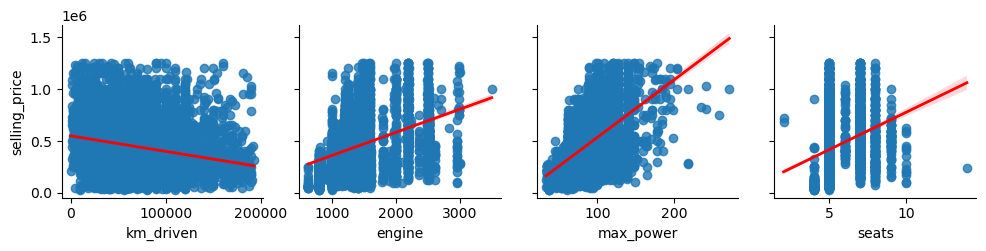

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(data_prep, y_vars='selling_price', x_vars=['km_driven', 'engine', 'max_power', 'seats'], kind='reg', plot_kws={'line_kws':{'color':'red', 'linewidth':2}})

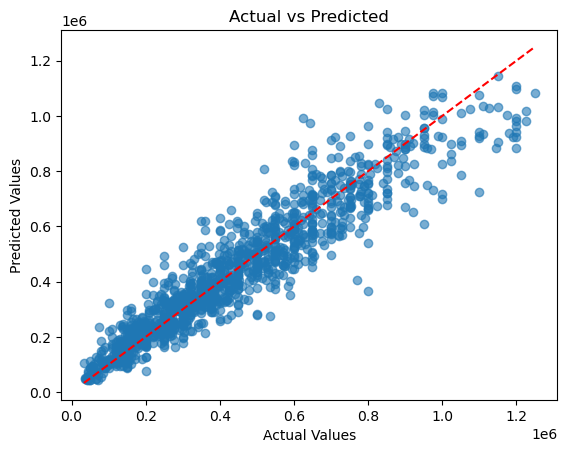

In [96]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

